In [ ]:
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
Torchvision version: 0.26.0+cu128
Device: cuda
GPU: Tesla T4


In [ ]:
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms

from torch.utils.data import DataLoader, Subset
from torchvision.datasets import CIFAR10

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import seaborn as sns
import pandas as pd
import time

In [ ]:
classes = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

print(classes)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [ ]:
transform_32 = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2470, 0.2435, 0.2616)
    )
])

transform_224 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.485, 0.456, 0.406),
        (0.229, 0.224, 0.225)
    )
])

In [ ]:
train_dataset_32 = CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform_32
)

test_dataset_32 = CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform_32
)

train_dataset_224 = CIFAR10(
    root="./data",
    train=True,
    download=False,
    transform=transform_224
)

test_dataset_224 = CIFAR10(
    root="./data",
    train=False,
    download=False,
    transform=transform_224
)

print("Training images:", len(train_dataset_32))
print("Testing images:", len(test_dataset_32))

100%|██████████| 170M/170M [35:55<00:00, 79.1kB/s]


Training images: 50000
Testing images: 10000


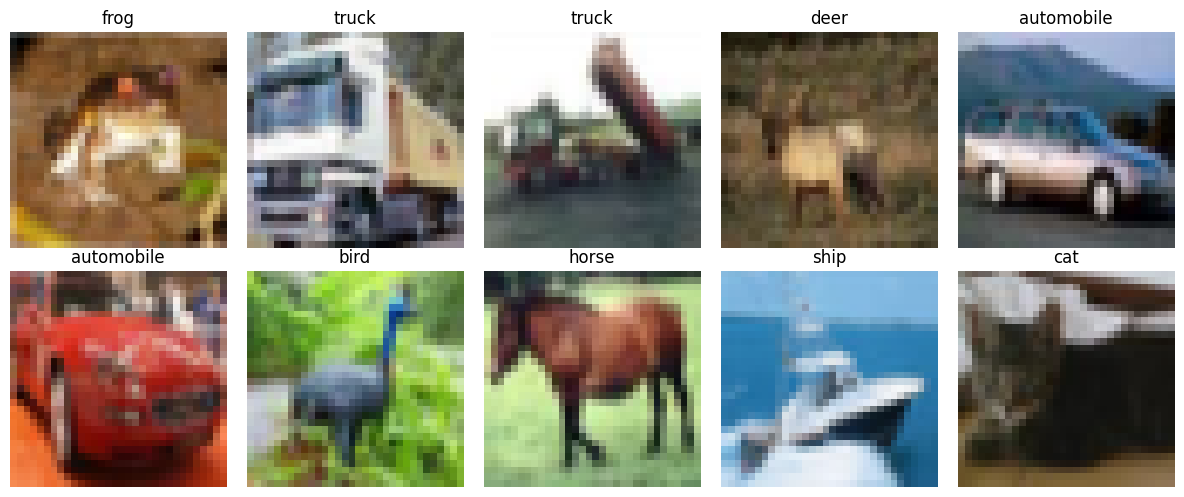

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    image, label = train_dataset_32[i]

    image = image.permute(1, 2, 0)

    # Undo normalization for visualization
    mean = torch.tensor([0.4914, 0.4822, 0.4465])
    std = torch.tensor([0.2470, 0.2435, 0.2616])

    image = image * std + mean
    image = torch.clamp(image, 0, 1)

    ax.imshow(image)
    ax.set_title(classes[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
BATCH_SIZE = 128

train_loader_32 = DataLoader(
    train_dataset_32,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader_32 = DataLoader(
    test_dataset_32,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

train_loader_224 = DataLoader(
    train_dataset_224,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader_224 = DataLoader(
    test_dataset_224,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [ ]:
class LeNet5(nn.Module):

    def __init__(self):
        super(LeNet5, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 6, kernel_size=5),
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2),

            nn.Conv2d(6, 16, kernel_size=5),
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 5 * 5, 120),
            nn.ReLU(),

            nn.Linear(120, 84),
            nn.ReLU(),

            nn.Linear(84, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [ ]:
lenet = LeNet5().to(device)

print(lenet)

LeNet5(
  (features): Sequential(
    (0): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): ReLU()
    (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=400, out_features=120, bias=True)
    (2): ReLU()
    (3): Linear(in_features=120, out_features=84, bias=True)
    (4): ReLU()
    (5): Linear(in_features=84, out_features=10, bias=True)
  )
)


In [ ]:
def train_model(model, train_loader, epochs=3, learning_rate=0.001):

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    model.train()

    for epoch in range(epochs):

        running_loss = 0.0
        correct = 0
        total = 0

        start_time = time.time()

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Loss: {running_loss/len(train_loader):.4f} "
            f"Accuracy: {accuracy:.2f}% "
            f"Time: {time.time()-start_time:.1f}s"
        )

    return model

In [ ]:
def evaluate_model(model, test_loader):

    model.eval()

    all_labels = []
    all_predictions = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)

            outputs = model(images)

            _, predictions = torch.max(outputs, 1)

            all_labels.extend(labels.numpy())
            all_predictions.extend(predictions.cpu().numpy())

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    precision = precision_score(
        all_labels,
        all_predictions,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        all_labels,
        all_predictions,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        all_labels,
        all_predictions,
        average="weighted",
        zero_division=0
    )

    return accuracy, precision, recall, f1, all_labels, all_predictions

In [ ]:
lenet = LeNet5().to(device)

lenet = train_model(
    lenet,
    train_loader_32,
    epochs=5,
    learning_rate=0.001
)

Epoch [1/5] Loss: 1.7303 Accuracy: 36.73% Time: 13.2s
Epoch [2/5] Loss: 1.4251 Accuracy: 48.69% Time: 12.1s
Epoch [3/5] Loss: 1.3261 Accuracy: 52.40% Time: 11.9s
Epoch [4/5] Loss: 1.2604 Accuracy: 54.81% Time: 11.6s
Epoch [5/5] Loss: 1.2056 Accuracy: 56.98% Time: 11.9s


In [ ]:
from torchvision.models import alexnet, AlexNet_Weights

alexnet_model = alexnet(
    weights=AlexNet_Weights.DEFAULT
)

alexnet_model.classifier[6] = nn.Linear(
    alexnet_model.classifier[6].in_features,
    10
)

alexnet_model = alexnet_model.to(device)

print(alexnet_model)

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:02<00:00, 122MB/s]


AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [ ]:
alexnet_model = train_model(
    alexnet_model,
    train_loader_224,
    epochs=5,
    learning_rate=0.0001
)

Epoch [1/5] Loss: 0.5249 Accuracy: 81.65% Time: 91.1s
Epoch [2/5] Loss: 0.2832 Accuracy: 90.20% Time: 90.8s
Epoch [3/5] Loss: 0.1889 Accuracy: 93.44% Time: 93.0s
Epoch [4/5] Loss: 0.1358 Accuracy: 95.16% Time: 92.1s
Epoch [5/5] Loss: 0.1019 Accuracy: 96.45% Time: 93.1s


In [ ]:
results = {}
accuracy, precision, recall, f1, y_true, y_pred = evaluate_model(
    alexnet_model,
    test_loader_224
)

results["AlexNet"] = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1
}

print("AlexNet")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

AlexNet
Accuracy : 0.9131
Precision: 0.9139792486302826
Recall   : 0.9131
F1 Score : 0.9125217857650827


In [ ]:
from torchvision.models import vgg16, VGG16_Weights

vgg_model = vgg16(
    weights=VGG16_Weights.DEFAULT
)

vgg_model.classifier[6] = nn.Linear(
    vgg_model.classifier[6].in_features,
    10
)

vgg_model = vgg_model.to(device)

print(vgg_model)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:08<00:00, 64.0MB/s]


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [ ]:
vgg_model = train_model(
    vgg_model,
    train_loader_224,
    epochs=3,
    learning_rate=0.0001
)

Epoch [1/3] Loss: 0.4340 Accuracy: 85.17% Time: 743.7s
Epoch [2/3] Loss: 0.1969 Accuracy: 93.31% Time: 740.6s
Epoch [3/3] Loss: 0.1215 Accuracy: 95.79% Time: 743.3s


In [ ]:
accuracy, precision, recall, f1, y_true, y_pred = evaluate_model(
    vgg_model,
    test_loader_224
)

results["VGG16"] = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1
}

print("VGG16")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

VGG16
Accuracy : 0.9251
Precision: 0.9265129465733396
Recall   : 0.9251
F1 Score : 0.9250478815368323


In [ ]:
from torchvision.models import googlenet, GoogLeNet_Weights

googlenet_model = googlenet(
    weights=GoogLeNet_Weights.DEFAULT,
    aux_logits=True
)

googlenet_model.fc = nn.Linear(
    googlenet_model.fc.in_features,
    10
)

googlenet_model.aux1.fc2 = nn.Linear(
    googlenet_model.aux1.fc2.in_features,
    10
)

googlenet_model.aux2.fc2 = nn.Linear(
    googlenet_model.aux2.fc2.in_features,
    10
)

googlenet_model = googlenet_model.to(device)

print(googlenet_model)

Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth


100%|██████████| 49.7M/49.7M [00:00<00:00, 142MB/s]


GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track

/usr/local/lib/python3.12/dist-packages/torchvision/models/googlenet.py:341: UserWarning: auxiliary heads in the pretrained googlenet model are NOT pretrained, so make sure to train them
  warnings.warn(


In [ ]:
def train_googlenet(model, train_loader, epochs=3, learning_rate=0.0001):

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    for epoch in range(epochs):

        model.train()

        running_loss = 0
        correct = 0
        total = 0

        start_time = time.time()

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs, aux1, aux2 = model(images)

            loss1 = criterion(outputs, labels)
            loss2 = criterion(aux1, labels)
            loss3 = criterion(aux2, labels)

            loss = loss1 + 0.3 * loss2 + 0.3 * loss3

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Loss: {running_loss/len(train_loader):.4f} "
            f"Accuracy: {accuracy:.2f}% "
            f"Time: {time.time()-start_time:.1f}s"
        )

    return model

In [ ]:
googlenet_model = train_googlenet(
    googlenet_model,
    train_loader_224,
    epochs=3,
    learning_rate=0.0001
)

Epoch [1/3] Loss: 0.9144 Accuracy: 88.10% Time: 192.3s
Epoch [2/3] Loss: 0.3749 Accuracy: 96.38% Time: 190.5s
Epoch [3/3] Loss: 0.2410 Accuracy: 98.34% Time: 190.8s


In [ ]:
accuracy, precision, recall, f1, y_true, y_pred = evaluate_model(
    googlenet_model,
    test_loader_224
)

results["GoogLeNet"] = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1
}

print("GoogLeNet")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

GoogLeNet
Accuracy : 0.9508
Precision: 0.9508634240083935
Recall   : 0.9508
F1 Score : 0.9507334345974897


In [ ]:
from torchvision.models import resnet18, ResNet18_Weights

resnet_model = resnet18(
    weights=ResNet18_Weights.DEFAULT
)

resnet_model.fc = nn.Linear(
    resnet_model.fc.in_features,
    10
)

resnet_model = resnet_model.to(device)

print(resnet_model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 218MB/s]

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
resnet_model = train_model(
    resnet_model,
    train_loader_224,
    epochs=3,
    learning_rate=0.0001
)

Epoch [1/3] Loss: 0.3188 Accuracy: 89.46% Time: 150.2s
Epoch [2/3] Loss: 0.0951 Accuracy: 96.96% Time: 149.2s
Epoch [3/3] Loss: 0.0417 Accuracy: 98.74% Time: 149.4s


In [ ]:
accuracy, precision, recall, f1, y_true, y_pred = evaluate_model(
    resnet_model,
    test_loader_224
)

results["ResNet18"] = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1
}

print("ResNet18")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

ResNet18
Accuracy : 0.9406
Precision: 0.9423406819012337
Recall   : 0.9406
F1 Score : 0.9406708934391154


In [ ]:
results_df = pd.DataFrame(results).T

results_df

,Accuracy,Precision,Recall,F1-Score
AlexNet,0.9131,0.913979,0.9131,0.912522
VGG16,0.9251,0.926513,0.9251,0.925048
GoogLeNet,0.9508,0.950863,0.9508,0.950733
ResNet18,0.9406,0.942341,0.9406,0.940671


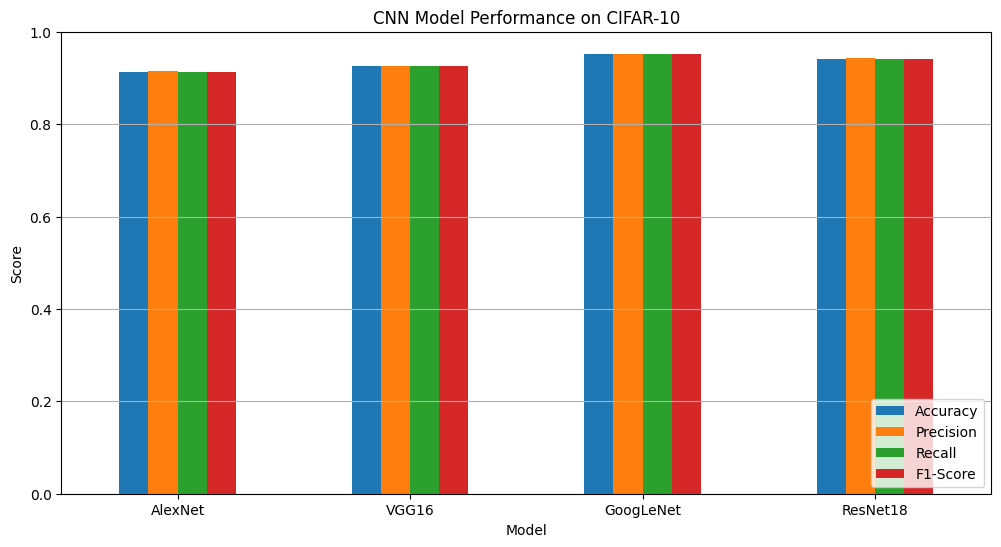

In [ ]:
results_df.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("CNN Model Performance on CIFAR-10")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.grid(axis="y")

plt.show()

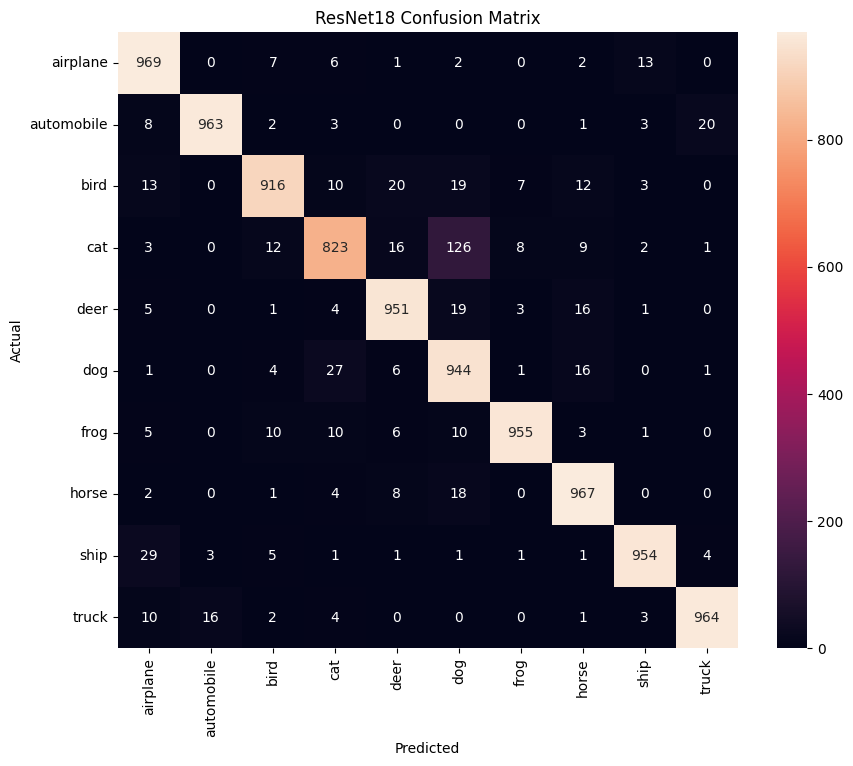

In [ ]:
accuracy, precision, recall, f1, y_true, y_pred = evaluate_model(
    resnet_model,
    test_loader_224
)

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ResNet18 Confusion Matrix")

plt.show()

In [ ]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=classes
    )
)

              precision    recall  f1-score   support

    airplane       0.93      0.97      0.95      1000
  automobile       0.98      0.96      0.97      1000
        bird       0.95      0.92      0.93      1000
         cat       0.92      0.82      0.87      1000
        deer       0.94      0.95      0.95      1000
         dog       0.83      0.94      0.88      1000
        frog       0.98      0.95      0.97      1000
       horse       0.94      0.97      0.95      1000
        ship       0.97      0.95      0.96      1000
       truck       0.97      0.96      0.97      1000

    accuracy                           0.94     10000
   macro avg       0.94      0.94      0.94     10000
weighted avg       0.94      0.94      0.94     10000

